In [146]:
from pathlib import Path

folder_path = Path('../data/processed/')

image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'}

image_path_objects = [
    file for file in folder_path.iterdir() 
    if file.is_file() and file.suffix.lower() in image_extensions
]

processed_image_list = [str(path) for path in image_path_objects]

print(f"Đã tìm thấy {len(processed_image_list)} ảnh.")
print(processed_image_list)

Đã tìm thấy 9 ảnh.
['..\\data\\processed\\img1.jpg', '..\\data\\processed\\img2.jpg', '..\\data\\processed\\img3.jpg', '..\\data\\processed\\img4.jpg', '..\\data\\processed\\img5.jpg', '..\\data\\processed\\img6.jpg', '..\\data\\processed\\img7.jpg', '..\\data\\processed\\img8.jpg', '..\\data\\processed\\img9.jpg']


In [147]:
folder_path = Path('../data/raw/')

image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'}

image_path_objects = [
    file for file in folder_path.iterdir() 
    if file.is_file() and file.suffix.lower() in image_extensions
]

raw_image_list = [str(path) for path in image_path_objects]

print(f"Đã tìm thấy {len(raw_image_list)} ảnh.")
print(raw_image_list)

Đã tìm thấy 8 ảnh.
['..\\data\\raw\\img1.jpg', '..\\data\\raw\\img2.jpg', '..\\data\\raw\\img3.jpg', '..\\data\\raw\\img4.jpg', '..\\data\\raw\\img5.jpg', '..\\data\\raw\\img6.jpg', '..\\data\\raw\\img7.jpg', '..\\data\\raw\\img8.jpg']


In [148]:
def detect_edges(img_gray, low_thresh=50, high_thresh=150):
    """
    Bước 1: Phát hiện biên bằng thuật toán Canny.
    """
    # Canny sẽ tìm các vùng có sự thay đổi độ sáng (gradient) đột ngột
    edges = cv2.Canny(img_gray, low_thresh, high_thresh)
    return edges



In [149]:
def get_lines (edges_img, threshold=150, minLineLength=100, maxLineGap=10):
    return cv2.HoughLinesP(
        edges_img, 
        1, 
        np.pi/180, 
        threshold=threshold, 
        minLineLength=minLineLength, 
        maxLineGap=maxLineGap
    )
    

In [150]:
def detect_and_draw_lines(edges_img, img_rgb, threshold=150, minLineLength=100, maxLineGap=10):
    """
    Bước 2: Tìm đường thẳng bằng Hough Transform và vẽ đè lên ảnh gốc.
    """
    # Tạo bản sao của ảnh gốc để vẽ cho an toàn
    img_with_lines = img_rgb.copy()
    
    # Sử dụng Probabilistic Hough Transform (HoughLinesP)
    # Các tham số: ảnh biên, độ phân giải rho (1 pixel), độ phân giải góc theta (1 độ),
    # threshold (số điểm tối thiểu để tạo thành đường), minLineLength, maxLineGap
    lines = get_lines(edges_img, threshold=threshold, minLineLength=minLineLength, maxLineGap=maxLineGap)
    
    # Nếu tìm thấy đường thẳng thì vẽ nó lên
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Vẽ đường thẳng màu Đỏ (255, 0, 0), độ dày 2 pixel
            cv2.line(img_with_lines, (x1, y1), (x2, y2), (255, 0, 0), 2)
            
    return img_with_lines

In [151]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_image(file_path):
    img = cv2.imread(file_path)
    if img is None:
        raise ValueError(f"Cannot find path.")
    return img

In [152]:
def resize_and_crop(img, target_width=800, target_height=600, crop_margin=50):
    """
    Resize x Crop
    """
    img_resized = cv2.resize(img, (target_width, target_height))
    
    img_cropped = img_resized[crop_margin : target_height - crop_margin, 
                              crop_margin : target_width - crop_margin]
    return img_cropped

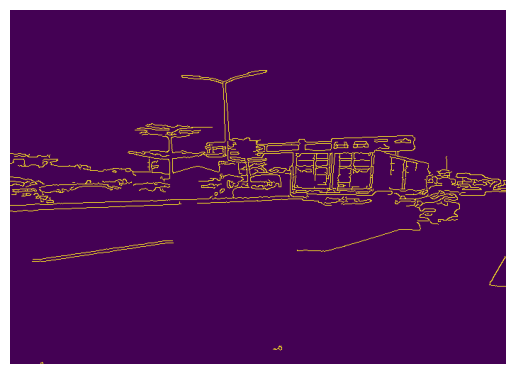

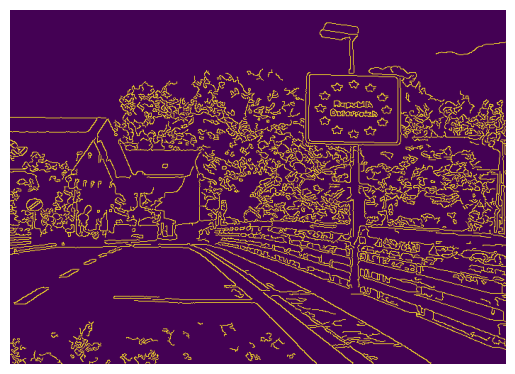

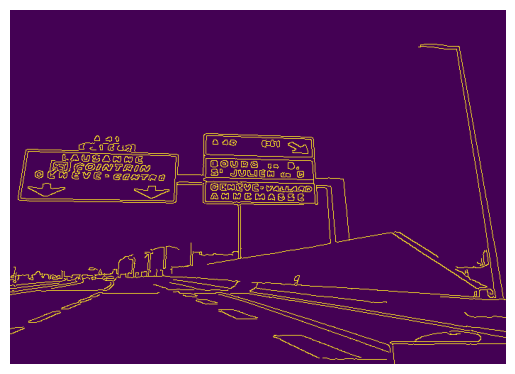

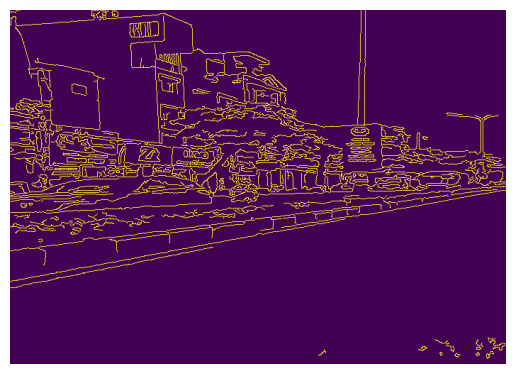

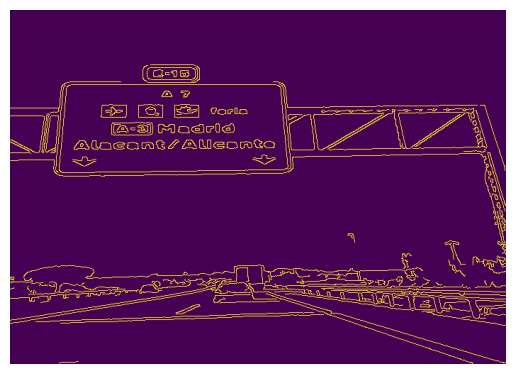

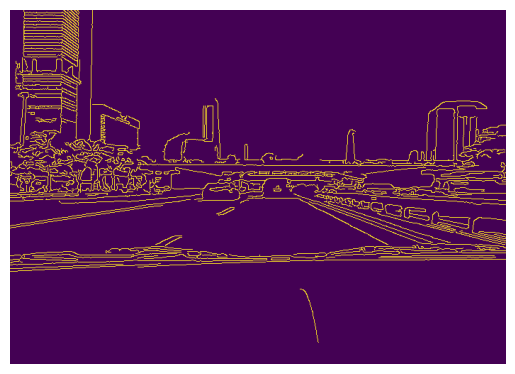

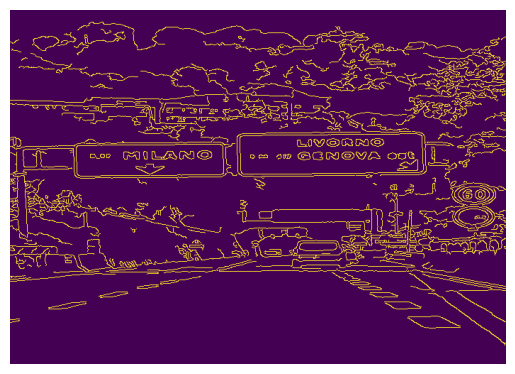

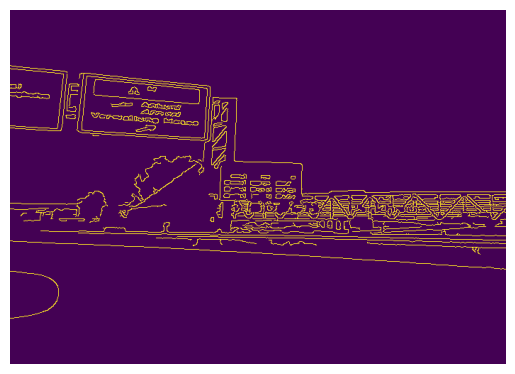

In [153]:
import cv2
import os

save_path = '../results/Images/Boundary_Dectection/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

for processed_img_path, raw_img_path in zip(processed_image_list, raw_image_list):
    processed_img = read_image(processed_img_path)
    raw_img = read_image(raw_img_path)

    img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)


    cropped_img = resize_and_crop(img_rgb)

    boundaries = detect_edges(processed_img, 100, 250)

    # Dùng os.path.basename để lấy tên file từ chuỗi
    ten_file = os.path.basename(processed_img_path)
    final_destination = os.path.join(save_path, ten_file)
    cv2.imwrite(final_destination, boundaries)

    

    plt.imshow(boundaries)
    plt.axis('off') # Ẩn viền/trục cho đẹp
    plt.show()      # In ảnh ra ngay lập tức
    

In [154]:
import numpy as np

def region_of_interest(img):
    height, width = img.shape
    # Định nghĩa hình thang bao phủ làn đường
    polygons = np.array([
        [(0, height), (width, height), (width, int(height * 0.3)), (0, int(height * 0.3))]
    ])
    mask = np.zeros_like(img)
    cv2.fillPoly(mask, polygons, 255)
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image


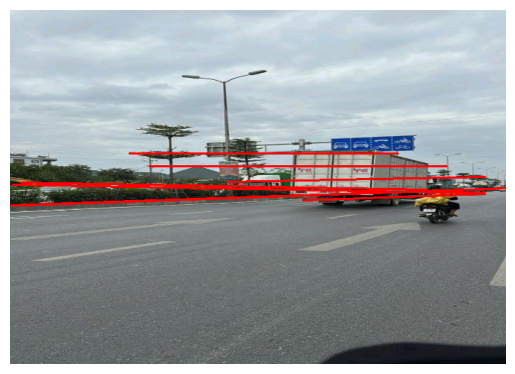

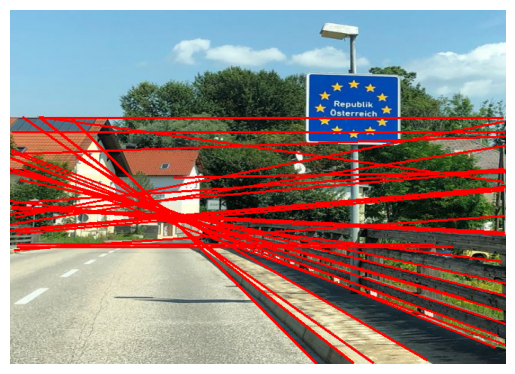

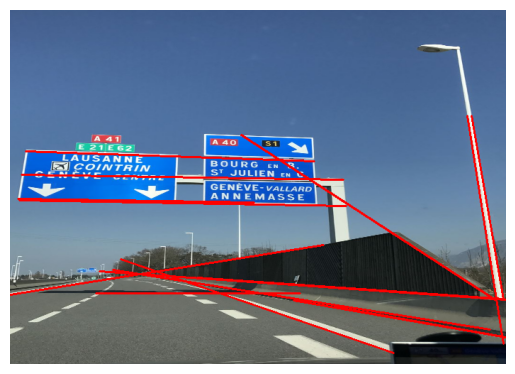

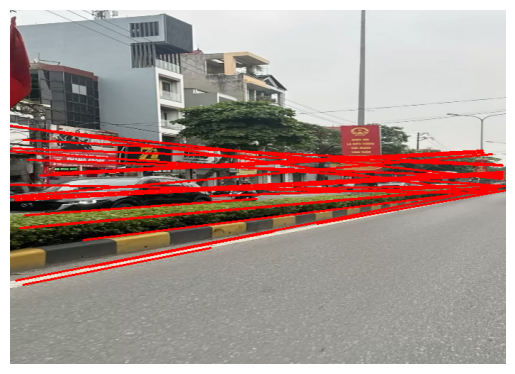

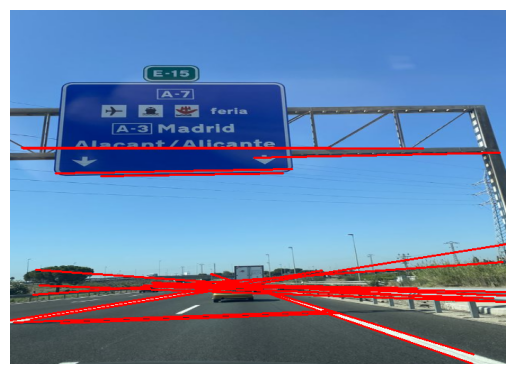

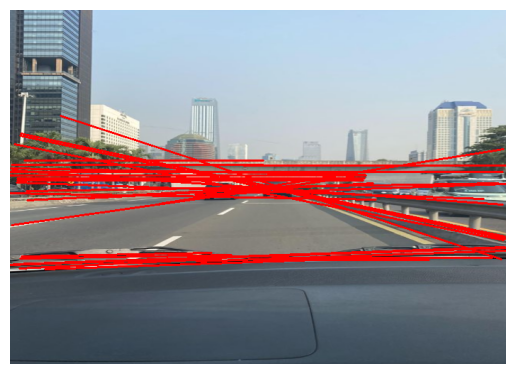

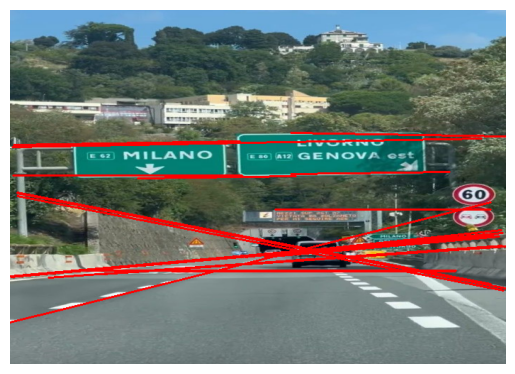

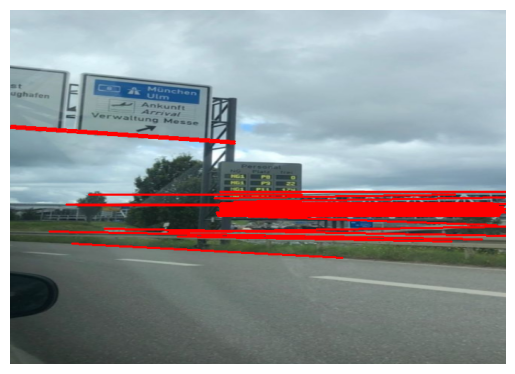

In [162]:
import cv2
import os

save_path = '../results/Images/Lines/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

for processed_img_path, raw_img_path in zip(processed_image_list, raw_image_list):
    processed_img = read_image(processed_img_path)
    raw_img = read_image(raw_img_path)

    img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    cropped_img = resize_and_crop(img_rgb)

    boundaries = detect_edges(processed_img, 100, 250)

    roi_boundaries = region_of_interest(boundaries)


    # Dùng os.path.basename để lấy tên file từ chuỗi
    ten_file = os.path.basename(processed_img_path)
    final_destination = os.path.join(save_path, ten_file)

    img_in_lines = detect_and_draw_lines(roi_boundaries, cropped_img,threshold=150, minLineLength=220, maxLineGap=80)

    cv2.imwrite(final_destination, img_in_lines)


    plt.imshow(img_in_lines)
    plt.axis('off') # Ẩn viền/trục cho đẹp
    plt.show()      # In ảnh ra ngay lập tức
    